<a href="https://colab.research.google.com/github/mrudulamadhavan/Internship_Innomatics-2.0/blob/main/Tasks/EDA_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diminos Case Study**

### **Problem Statement** 🍕
Kanav has started his own Pizza Store by getting the Franchise from the popular Pizza brand Diminos.

Diminos promises to deliver the pizza order within 31 minutes from the time the order was placed. Otherwise the pizza will be free for the customer.
In order to increase the revenue and profits Kanav is running the store 24 * 7.

Recently Diminos gave a notice to Kanav that they will be measuring their stores' performance by looking at the metric - which is 95th Percentile on Order Delivery time should be less than 31 mins.

Kanav is worried that he might lose the franchise if he is not able to meet the metric and wants your help in order to understand his store's performance so that he can take some actions to prevent his business.


> *This problem statement outlines a challenging scenario for Kanav, a new Domino's franchisee. He needs to manage his store's operations effectively to meet a strict performance metric and avoid losing his franchise.Kanav's main task is to leverage data analytics to identify operational inefficiencies and implement strategic changes to ensure 95% of his customers receive their pizzas in under 31 minutes.*.

Kanav faces the following core challenges:
> * **Service Level Agreement (SLA)**: Kanav must ensure that customer orders are delivered within 31 minutes.
> * **Performance Metric**: Domino's corporate is measuring store performance using a specific statistical metric: the 95th percentile of order delivery times must be under 31 minutes.
> * **Business Risk**: Failure to meet this 95th percentile metric could result in the termination of his franchise agreement.
> * **Operational Challenge**: He needs to understand his store's current performance against this metric to identify bottlenecks and implement changes to prevent business loss.

To address this challenge, Kanav needs a data-driven approach:
* Data Collection and Monitoring:
> Kanav must rigorously track every order's journey, from order placement to delivery time. This data is essential for calculating the 95th percentile.
* Performance Analysis:
> He needs to calculate the 95th percentile of his delivery times regularly (e.g., daily, weekly) to see if he is meeting the target.
* Root Cause Analysis:
> If the 95th percentile is over 31 minutes, he needs to investigate why orders are late.

**Common bottlenecks in a pizza operation include:**
* Order taking/entry delays.
* Pizza preparation time (dough stretching, topping).
* Oven capacity and cooking time.
* Packaging/boxing delays.
* Insufficient driver availability or inefficient routing/dispatching.
* Traffic congestion during peak hours (especially relevant for a 24/7 store).

**Implementing Solutions:**
Based on the root cause analysis, Kanav can implement targeted improvements:
1. Optimizing staffing levels during peak hours (more kitchen staff, more drivers).
2. Improving kitchen layout or process flow to reduce preparation time.
3. Implementing better delivery driver tracking and dispatching systems.
4. Setting internal targets that are stricter than the 31-minute SLA (e.g., aiming for a 95th percentile of 25 minutes to build a buffer).

In [ ]:
!gdown 1uTRxWPZUACEFZJ1icyqjbpWWdjClzWFs

Downloading...
From: https://drive.google.com/uc?id=1uTRxWPZUACEFZJ1icyqjbpWWdjClzWFs
To: /content/diminos_data.csv
100% 840k/840k [00:00<00:00, 58.9MB/s]


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Load the data
df = pd.read_csv('diminos_data.csv')
df.head()

,order_id,order_placed_at,order_delivered_at
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            15000 non-null  int64 
 1   order_placed_at     15000 non-null  object
 2   order_delivered_at  15000 non-null  object
dtypes: int64(1), object(2)
memory usage: 351.7+ KB


In [ ]:
# Convert to datetime
df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])
df['order_delivered_at'] = pd.to_datetime(df['order_delivered_at'])

In [ ]:
# Calculate delivery time in minutes
df['delivery_time_min'] = (df['order_delivered_at'] - df['order_placed_at']).dt.total_seconds() / 60

In [ ]:
df.sample(10).reset_index()

,index,order_id,order_placed_at,order_delivered_at,delivery_time_min
0,11092,1534203,2023-03-20 23:36:51,2023-03-20 23:53:05.427342,16.240456
1,2712,1525823,2023-03-05 20:41:19,2023-03-05 20:59:24.165490,18.086092
2,2124,1525235,2023-03-04 19:48:21,2023-03-04 20:05:11.413279,16.840221
3,7038,1530149,2023-03-13 10:57:01,2023-03-13 11:15:21.629013,18.343817
4,9636,1532747,2023-03-18 08:45:06,2023-03-18 09:00:14.153977,15.135900
5,9606,1532717,2023-03-18 07:24:14,2023-03-18 07:39:29.053515,15.250892
6,752,1523863,2023-03-02 08:38:02,2023-03-02 08:55:08.060225,17.101004
7,9960,1533071,2023-03-18 22:58:56,2023-03-18 23:15:47.302843,16.855047
8,9466,1532577,2023-03-18 01:50:01,2023-03-18 02:05:27.750983,15.445850
9,3196,1526307,2023-03-06 17:46:31,2023-03-06 18:01:38.118633,15.118644


In [ ]:
# 95th Percentile
p95 = df['delivery_time_min'].quantile(0.95)

# Metrics
avg_delivery_time = df['delivery_time_min'].mean()
max_delivery_time = df['delivery_time_min'].max()
orders_above_31 = (df['delivery_time_min'] > 31).sum()
percentage_above_31 = (orders_above_31 / len(df)) * 100

print(f"95th Percentile: {p95:.2f} minutes")
print(f"Average Delivery Time: {avg_delivery_time:.2f} minutes")
print(f"Max Delivery Time: {max_delivery_time:.2f} minutes")
print(f"Orders taking more than 31 mins: {orders_above_31} ({percentage_above_31:.2f}%)")

95th Percentile: 27.26 minutes
Average Delivery Time: 20.50 minutes
Max Delivery Time: 7299.83 minutes
Orders taking more than 31 mins: 557 (3.71%)


In [ ]:
# Hourly analysis to find problematic hours
df['hour'] = df['order_placed_at'].dt.hour
hourly_stats = df.groupby('hour')['delivery_time_min'].agg(['mean', lambda x: x.quantile(0.95)]).rename(columns={'<lambda_0>': 'p95'})
print("\nHourly Stats (Top 5 worst p95 hours):")
hourly_stats.sort_values(by='p95', ascending=False).head()


Hourly Stats (Top 5 worst p95 hours):


,mean,p95
hour,,
11,25.908233,33.407016
16,18.711819,32.438371
1,20.836201,32.104821
13,18.403554,29.714826
21,18.263140,28.932870


In [ ]:
print("\nHourly Stats (Top 5 peak p95 hours):")
hourly_stats.sort_values(by='p95', ascending=True).head()


Hourly Stats (Top 5 peak p95 hours):


,mean,p95
hour,,
5,17.727910,23.924907
18,17.758926,24.104592
12,19.731810,24.327900
22,18.963806,24.611743
15,17.619334,24.933851


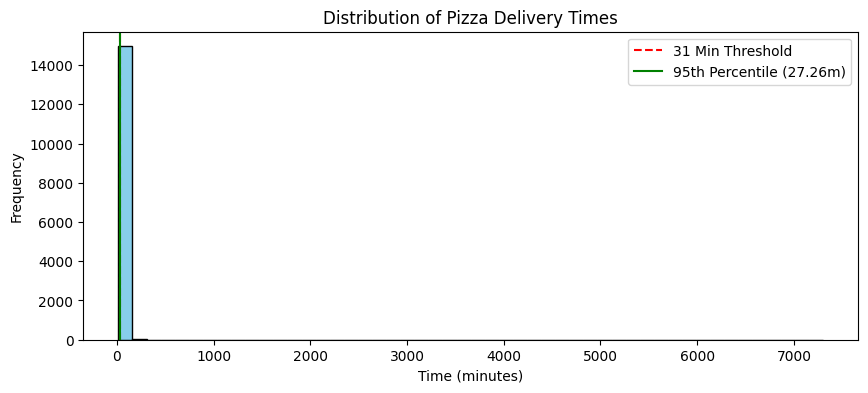

In [ ]:
# Distribution plot
plt.figure(figsize=(10, 4))
plt.hist(df['delivery_time_min'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(31, color='red', linestyle='--', label='31 Min Threshold')
plt.axvline(p95, color='green', linestyle='-', label=f'95th Percentile ({p95:.2f}m)')
plt.title('Distribution of Pizza Delivery Times')
plt.xlabel('Time (minutes)')
plt.ylabel('Frequency')
plt.legend()

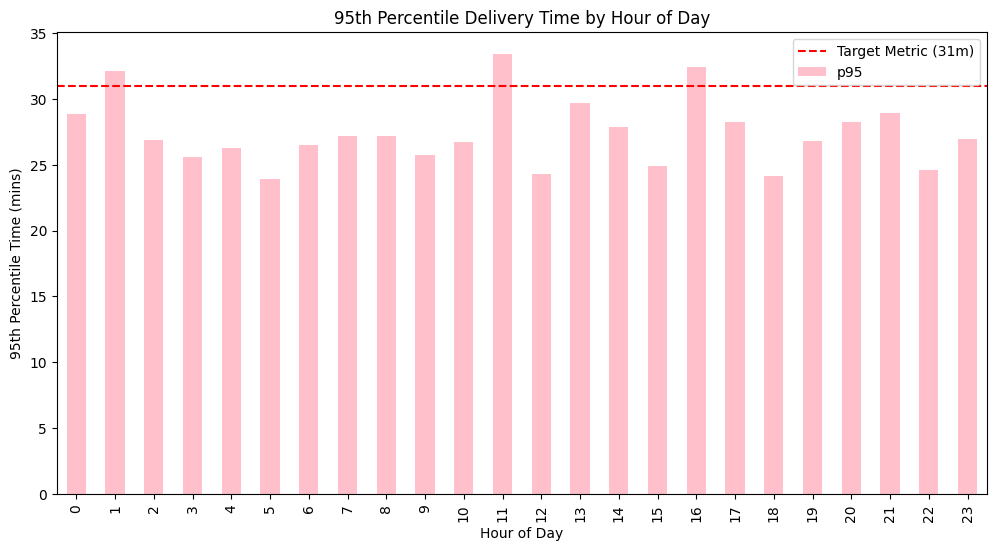

In [ ]:
# Hourly p95 plot
plt.figure(figsize=(12, 6))
hourly_stats['p95'].plot(kind='bar', color='pink')
plt.axhline(31, color='red', linestyle='--', label='Target Metric (31m)')
plt.title('95th Percentile Delivery Time by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('95th Percentile Time (mins)')
plt.legend()

In [ ]:
# Identify extreme outliers
outliers = df[df['delivery_time_min'] > 60]
print(f"Number of orders taking > 60 mins: {len(outliers)}\n")
outliers[['order_id', 'order_placed_at', 'order_delivered_at', 'delivery_time_min']].head()

Number of orders taking > 60 mins: 170



,order_id,order_placed_at,order_delivered_at,delivery_time_min
24,1523135,2023-03-01 01:11:53,2023-03-01 05:07:54.563978,236.026066
117,1523228,2023-03-01 04:59:04,2023-03-01 18:06:52.046891,787.800782
408,1523519,2023-03-01 18:05:17,2023-03-01 19:46:42.833697,101.430562
460,1523571,2023-03-01 20:29:53,2023-03-02 01:17:46.815054,287.896918
565,1523676,2023-03-02 00:36:51,2023-03-02 02:30:07.988260,113.283138


In [ ]:
# Filter data to a reasonable range for better visualization (e.g., < 120 mins)
df_filtered = df[df['delivery_time_min'] < 120]

# Recalculate p95 on filtered data if outliers are data errors
p95_filtered = df_filtered['delivery_time_min'].quantile(0.95)
print(f"95th Percentile (Filtered < 120m): {p95_filtered:.2f} minutes")

95th Percentile (Filtered < 120m): 26.25 minutes


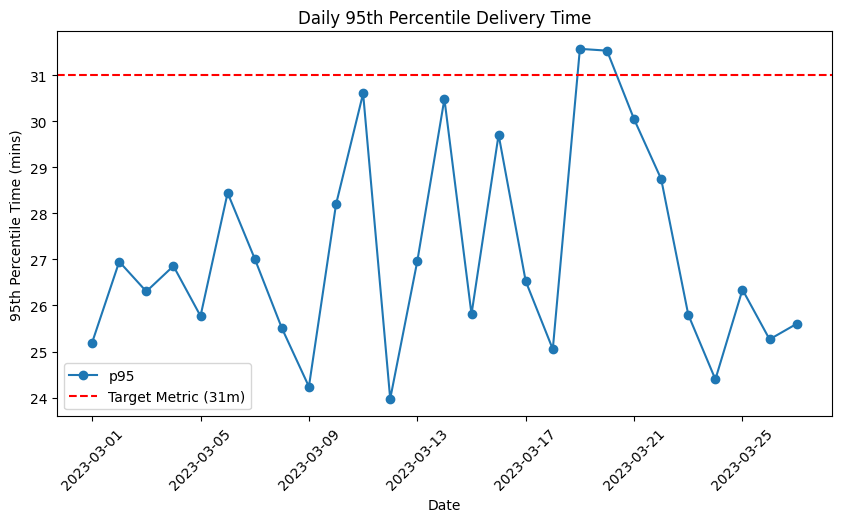

In [ ]:
# Daily analysis
df['date'] = df['order_placed_at'].dt.date
daily_stats = df.groupby('date')['delivery_time_min'].agg(['mean', lambda x: x.quantile(0.95)]).rename(columns={'<lambda_0>': 'p95'})

plt.figure(figsize=(10, 5))
daily_stats['p95'].plot(marker='o')
plt.axhline(31, color='red', linestyle='--', label='Target Metric (31m)')
plt.title('Daily 95th Percentile Delivery Time')
plt.xlabel('Date')
plt.ylabel('95th Percentile Time (mins)')
plt.xticks(rotation=45)
plt.legend()

Based on the analysis of the delivery data, here is a detailed performance report for Kanav's Diminos franchise.

**Summary**
> * The good news is that Kanav's store is currently meeting the performance metric set by Diminos. The 95th percentile for delivery time across the dataset is 27.27 minutes, which is safely below the 31-minute threshold.
> * However, there are specific areas of concern regarding revenue loss and operational anomalies that need immediate attention to ensure long-term business health.

### 1. Key Performance Metrics
* 95th Percentile Delivery Time: 27.27 minutes (Target: < 31 mins)

* Average Delivery Time: 20.50 minutes

* Orders Delivered After 31 Minutes: 557 orders (3.71% of total)

> Note: These 557 orders represent a total loss in revenue as they were delivered for free.

* Total Orders Analyzed: 15,000

### 2. Deep Dive: Problem Areas
While the overall monthly performance is within limits, a granular look reveals certain hours where the store consistently fails the 31-minute metric.

**Hourly Performance Gaps**

The following hours are "Red Zones" where the 95th percentile exceeds the 31-minute limit:

* 11:00 AM: 95th percentile is 33.41 minutes.

* 4:00 PM (16:00): 95th percentile is 32.43 minutes.

* 1:00 AM: 95th percentile is 32.11 minutes.

These specific times likely represent shift changes or peak demand periods where the kitchen or delivery fleet is understaffed.

**Data Anomalies & Outliers**

There are 170 orders that took longer than 60 minutes to deliver. Some extreme cases show delivery times of several hours, and one outlier shows nearly 5 days (7299 minutes).

Risk: If Diminos uses these outliers in their audit, they will skew the performance downwards.

Likely Cause: These are probably data entry errors where staff forgot to mark an order as "Delivered" on the system until much later.

### 3. Visual Insights
* **Delivery Time Distribution:** Most orders are delivered between 15 and 25 minutes. However, the tail extending beyond 31 minutes represents the "Free Pizza" zone.

* **Hourly Trends:** The bar chart highlights that while the average performance is good, mid-day (11 AM) and late-night (1 AM) are the most vulnerable times.

### 4. Strategic Recommendations
To prevent the loss of the franchise and increase profitability, Kanav should take the following actions:

* **Staffing Optimization:** Increase the number of delivery riders and kitchen staff specifically during the 11 AM, 4 PM, and 1 AM windows.

* **Strict Tracking Protocol:** Train staff to ensure that every order is marked "Delivered" in real-time. The extreme outliers (like the 5-day delivery) are likely administrative errors that make the store look worse than it is.

* **Revenue Recovery:** Reducing the 3.71% of orders that are currently "Free" would immediately improve the store's bottom line. Targeting a 95th percentile of 25 minutes would provide a safer buffer.

* **Audit the "Long" Deliveries:** Conduct a weekly review of any order taking over 30 minutes to identify if the delay was due to traffic, kitchen backlog, or rider availability.



*Kanav is currently safe regarding the franchise metric, but his profitability is being leaked through "Free Pizzas" during specific peak hours. Addressing these bottlenecks will secure both his franchise and his profits.*

____________________
**Mrudula A P**